# 04 · Predicting Late Deliveries (ML)

**Question:** at the moment an order is placed, can we predict whether it will be delivered late?
If yes, operations can upgrade the carrier or warn the customer in advance.

**Avoiding data leakage:** columns that are only known *after* shipping (`actual_days`,
`delay_days`, `delivery_status`, `shipping_date`) are **not** used as features.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from config import CLEAN_ITEMS_PATH, CLEAN_ORDERS_PATH, IMAGES
from viz import set_style, label_bars, BLUE, ORANGE, AQUA, MUTED, TEXT_2

set_style()
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 40)

import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from config import MODELS, SEED

orders = pd.read_csv(CLEAN_ORDERS_PATH, parse_dates=["order_date"])
df = orders[orders["is_cancelled"] == 0].copy()
df["order_month_num"] = df["order_date"].dt.month
print(f"Modelling rows: {len(df):,} | late share: {100 * df['is_late'].mean():.1f}%")

Modelling rows: 11,232 | late share: 57.4%

## 1. Features and train/test split

In [2]:
categorical = ["shipping_mode", "market", "region", "customer_segment", "payment_type", "order_weekday"]
numeric = ["scheduled_days", "order_month_num", "order_hour", "n_items", "units", "net_sales", "discount"]
X, y = df[categorical + numeric], df["is_late"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric),
])
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

Train: 8,985  Test: 2,247

## 2. Train and compare models

In [3]:
models = {
    "Baseline (always 'late')": None,
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                            random_state=SEED, n_jobs=-1),
}
results, fitted = [], {}
for name, clf in models.items():
    if clf is None:
        pred = np.ones(len(y_test), dtype=int); proba = np.full(len(y_test), 0.5)
    else:
        pipe = Pipeline([("pre", pre), ("clf", clf)]).fit(X_train, y_train)
        fitted[name] = pipe
        pred, proba = pipe.predict(X_test), pipe.predict_proba(X_test)[:, 1]
    results.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                    "precision": precision_score(y_test, pred), "recall": recall_score(y_test, pred),
                    "f1": f1_score(y_test, pred), "roc_auc": roc_auc_score(y_test, proba)})
results = pd.DataFrame(results).set_index("model").round(3)
results

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline (always 'late'),0.57,0.57,1.00,0.73,0.50
Logistic Regression,0.68,0.86,0.53,0.66,0.74
Random Forest,0.68,0.85,0.54,0.66,0.74


In [4]:
best_name = results.drop(index="Baseline (always 'late')")["roc_auc"].idxmax()
best = fitted[best_name]
pred = best.predict(X_test)
print("Best model:", best_name)
print(classification_report(y_test, pred, target_names=["On time", "Late"]))

Best model: Random Forest
              precision    recall  f1-score   support

     On time       0.58      0.87      0.70       957
        Late       0.85      0.54      0.66      1290

    accuracy                           0.68      2247
   macro avg       0.72      0.71      0.68      2247
weighted avg       0.74      0.68      0.68      2247

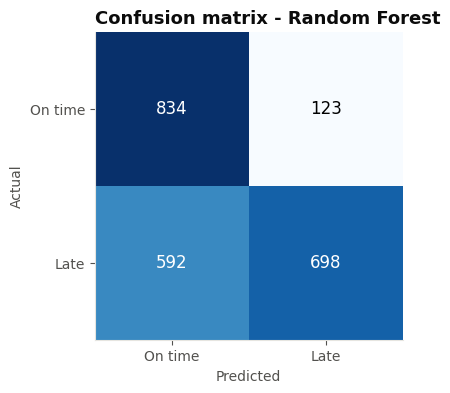

In [5]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.grid(False)
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center", color="white" if v > cm.max() / 2 else "black", fontsize=12)
ax.set_xticks([0, 1], ["On time", "Late"]); ax.set_yticks([0, 1], ["On time", "Late"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix - {best_name}")
plt.savefig(IMAGES / "10_confusion_matrix.png")

## 3. What drives late deliveries?

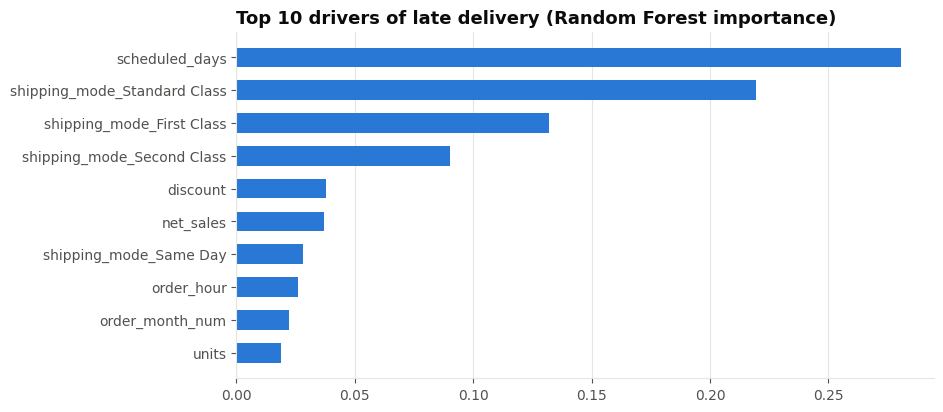

In [6]:
rf = fitted["Random Forest"]
names = rf.named_steps["pre"].get_feature_names_out()
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=names)
imp.index = imp.index.str.replace("cat__", "").str.replace("num__", "")
top = imp.sort_values().tail(10)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top.index, top.values, color=BLUE, height=0.6)
ax.set_title("Top 10 drivers of late delivery (Random Forest importance)")
ax.grid(axis="y", visible=False)
plt.savefig(IMAGES / "11_feature_importance.png")

**Interpretation:** shipping mode (and its promised `scheduled_days`) dominates the prediction -
the same conclusion as the KPI analysis. Order value, time and region add only small signal. So the
most effective fix is operational: **re-set delivery promises for First/Second Class** or change the
carrier for those services.

In [7]:
MODELS.mkdir(exist_ok=True)
joblib.dump(best, MODELS / "late_delivery_model.joblib", compress=3)
print("Saved model ->", "models/late_delivery_model.joblib")

Saved model -> models/late_delivery_model.joblib